In [1]:
import pandas as pd

data = {
    "study_hours": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
    "sleep_hours": [6, 7, 6, 8, 7, 8, 7, 9, 8, 9],
    "attendance": [60, 65, 70, 75, 80, 82, 85, 88, 92, 95],
    "marks": [45, 50, 55, 65, 68, 75, 78, 85, 90, 95]
}

df = pd.DataFrame(data)

df

,study_hours,sleep_hours,attendance,marks
0,2,6,60,45
1,3,7,65,50
2,4,6,70,55
3,5,8,75,65
4,6,7,80,68
5,7,8,82,75
6,8,7,85,78
7,9,9,88,85
8,10,8,92,90
9,11,9,95,95


In [2]:
df.to_csv("student_marks_multiple.csv", index=False)

In [3]:
print(df.head())
print(df.shape)

   study_hours  sleep_hours  attendance  marks
0            2            6          60     45
1            3            7          65     50
2            4            6          70     55
3            5            8          75     65
4            6            7          80     68
(10, 4)


In [4]:
X = df[["study_hours", "sleep_hours", "attendance"]]
y = df["marks"]

In [5]:
print("Input features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input features:
   study_hours  sleep_hours  attendance
0            2            6          60
1            3            7          65
2            4            6          70
3            5            8          75
4            6            7          80

Target:
0    45
1    50
2    55
3    65
4    68
Name: marks, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8, 3)
X_test: (2, 3)
y_train: (8,)
y_test: (2,)


In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [9]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [3.45341305 1.79123069 0.39760837]
Intercept: 3.3084205281514585


In [11]:
coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficient_table

,Feature,Coefficient
0,study_hours,3.453413
1,sleep_hours,1.791231
2,attendance,0.397608


In [12]:
print(
    f"Marks = {model.intercept_:.2f} "
    f"+ ({model.coef_[0]:.2f} × Study Hours) "
    f"+ ({model.coef_[1]:.2f} × Sleep Hours) "
    f"+ ({model.coef_[2]:.2f} × Attendance)"
)

Marks = 3.31 + (3.45 × Study Hours) + (1.79 × Sleep Hours) + (0.40 × Attendance)


In [13]:
y_pred = model.predict(X_test)

print("Predicted Marks:")
print(y_pred)

Predicted Marks:
[88.75236672 52.05181863]


In [14]:
comparison = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred
})

comparison

,Actual Marks,Predicted Marks
0,90,88.752367
1,50,52.051819


In [15]:
new_student = pd.DataFrame({
    "study_hours": [8],
    "sleep_hours": [8],
    "attendance": [90]
})

prediction = model.predict(new_student)

print("Predicted Marks:", prediction[0])

Predicted Marks: 81.05032386646735


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 1.6497259591429945
MSE: 2.883274260069803
R² Score: 0.9927918143498254


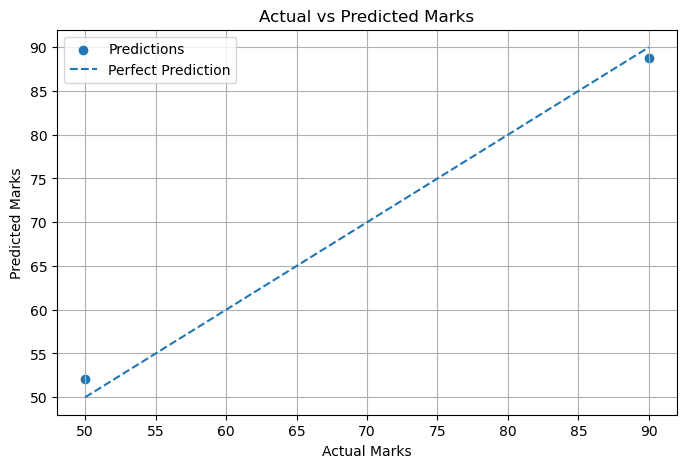

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Actual vs predicted points
plt.scatter(y_test, y_pred, label="Predictions")

# Ideal prediction line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
correlation_matrix = df.corr()

correlation_matrix

,study_hours,sleep_hours,attendance,marks
study_hours,1.000000,0.798447,0.992466,0.996938
sleep_hours,0.798447,1.000000,0.791031,0.826875
attendance,0.992466,0.791031,1.000000,0.994049
marks,0.996938,0.826875,0.994049,1.000000


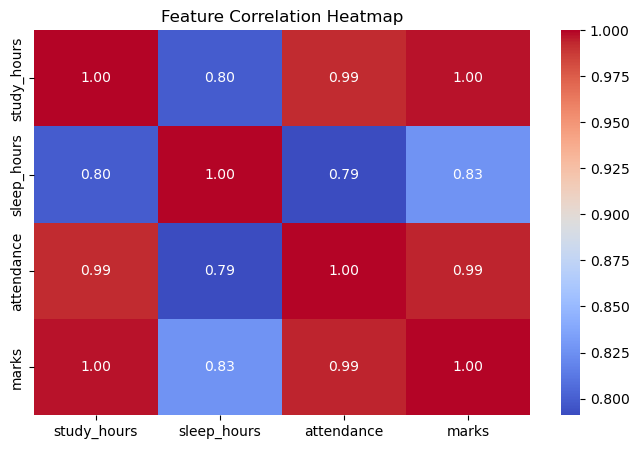

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data

,Feature,VIF
0,study_hours,14.451144
1,sleep_hours,142.114361
2,attendance,181.818855


In [24]:
residuals = y_test - y_pred

print("Residuals:")
print(residuals)

Residuals:
8    1.247633
1   -2.051819
Name: marks, dtype: float64


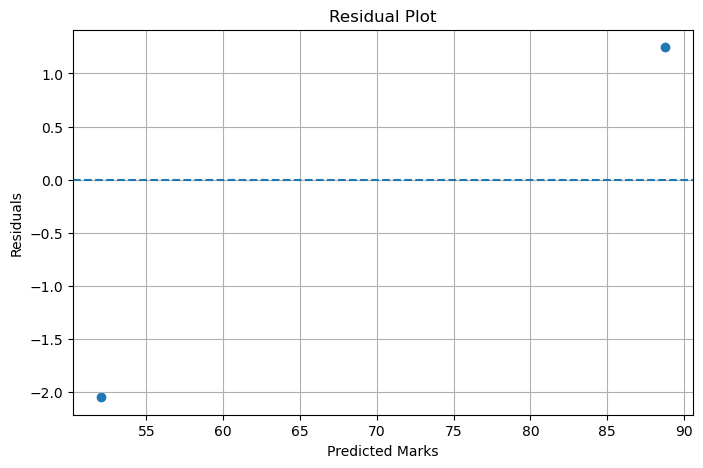

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Marks")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)

plt.show()

Dataset:
   study_hours  sleep_hours  attendance  marks
0            2            6          60     45
1            3            7          65     50
2            4            6          70     55
3            5            8          75     65
4            6            7          80     68
5            7            8          82     75
6            8            7          85     78
7            9            9          88     85
8           10            8          92     90
9           11            9          95     95

Intercept: 3.3084205281514585

Coefficients:
study_hours : 3.453413054309916
sleep_hours : 1.791230692575983
attendance : 0.3976083707025412

Predictions:
[88.75236672 52.05181863]

Model Evaluation:
MAE: 1.6497259591429945
MSE: 2.883274260069803
R² Score: 0.9927918143498254

Actual vs Predicted:
   Actual Marks  Predicted Marks
0            90        88.752367
1            50        52.051819

New Student Prediction: 81.05032386646735


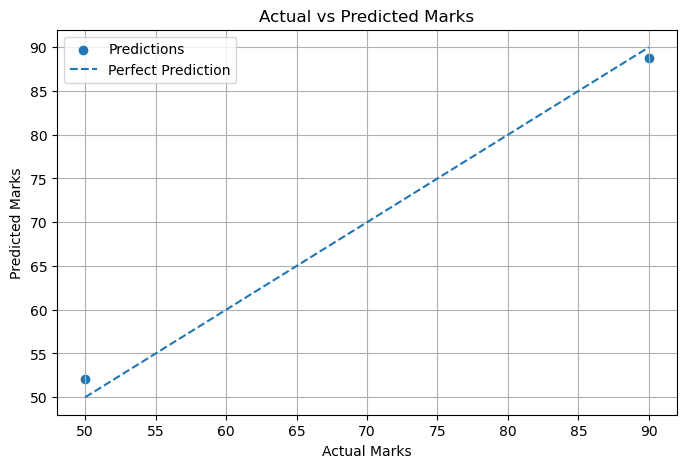

In [26]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 2. Load dataset
df = pd.read_csv("student_marks_multiple.csv")

print("Dataset:")
print(df)

# 3. Separate input features and target
X = df[["study_hours", "sleep_hours", "attendance"]]
y = df["marks"]

# 4. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 5. Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Display coefficients
print("\nIntercept:", model.intercept_)

print("\nCoefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

# 7. Make predictions
y_pred = model.predict(X_test)

print("\nPredictions:")
print(y_pred)

# 8. Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

# 9. Compare actual and predicted values
comparison = pd.DataFrame({
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred
})

print("\nActual vs Predicted:")
print(comparison)

# 10. Predict marks for a new student
new_student = pd.DataFrame({
    "study_hours": [8],
    "sleep_hours": [8],
    "attendance": [90]
})

new_prediction = model.predict(new_student)

print("\nNew Student Prediction:", new_prediction[0])

# 11. Actual vs Predicted graph
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred, label="Predictions")

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.legend()
plt.grid(True)

plt.show()